In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeCV, LassoCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    make_scorer,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    GridSearchCV,
)

In [9]:
def get_data():
    """
    Function to load the ATP tennis matches dataset from 2004 to 2024.
    The dataset is hosted on GitHub and contains match statistics.
    """
    base = "https://raw.githubusercontent.com/JeffSackmann/tennis_atp/master"
    years = range(2004, 2025)
    dfs = []
    for y in years:
        url = f"{base}/atp_matches_{y}.csv"
        dfs.append(pd.read_csv(url))
    # Concatenate all dataframes into one
    matches_df = pd.concat(dfs, ignore_index=True)
    # Reset index
    matches_df.reset_index(drop=True, inplace=True)

    # Turn all nan values into 0
    matches_df.fillna(0, inplace=True)

    FEATURES = [
        "w_ace",
        "w_1stWon",
        "w_2ndWon",
        "w_svpt",
        "best_of",
        # "l_ace", # Comment out when using the winner model
        # "l_1stWon",
    ]

    TARGET = [
        # "ace_diff",
        # "1stWon_diff",
        # "2ndWon_diff",
        # "svpt_diff",
        "ace_perc",
        "1stWon_perc",
        "2ndWon_perc",
        "svpt_perc",
    ]

    matches_df["ace_diff"] = (matches_df["w_ace"] - matches_df["l_ace"]) / matches_df[
        "best_of"
    ]
    matches_df["1stWon_diff"] = (
        matches_df["w_1stWon"] - matches_df["l_1stWon"]
    ) / matches_df["best_of"]
    matches_df["2ndWon_diff"] = (
        matches_df["w_2ndWon"] - matches_df["l_2ndWon"]
    ) / matches_df["best_of"]
    matches_df["svpt_diff"] = (
        matches_df["w_svpt"] - matches_df["l_svpt"]
    ) / matches_df["best_of"]

    matches_df["ace_perc"] = matches_df["w_ace"] / (
        matches_df["w_ace"] + matches_df["l_ace"]
    )
    matches_df["1stWon_perc"] = matches_df["w_1stWon"] / (
        matches_df["w_1stWon"] + matches_df["l_1stWon"]
    )
    matches_df["2ndWon_perc"] = matches_df["w_2ndWon"] / (
        matches_df["w_2ndWon"] + matches_df["l_2ndWon"]
    )
    matches_df["svpt_perc"] = matches_df["w_svpt"] / (
        matches_df["w_svpt"] + matches_df["l_svpt"]
    )

    X = matches_df[FEATURES]
    y = matches_df[TARGET]

    # Drop nan values
    combined = matches_df[FEATURES + TARGET].dropna()
    # Reset index
    X = combined[FEATURES].reset_index(drop=True)
    y = combined[TARGET].reset_index(drop=True)

    return X, y


def plot_data(X, y):
    """
    Function to plot the data using seaborn and matplotlib.
    """
    # Set the style of seaborn
    sns.set(style="whitegrid")

    # Create a pairplot for the features
    sns.pairplot(X)
    plt.show()

    # Create a heatmap for the correlation matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Correlation Matrix")
    plt.show()


def train_logistic_regression(X, y, cv_folds=5):
    """
    Train a logistic regression model with stratified K‑fold cross‑validation.
    Converts 'ace_perc' into a binary target (1 if >0.5, else 0).
    """
    # 1. Binarize the target
    y_binary = (y["ace_perc"] > 0.5).astype(int)

    # 2. Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_binary, test_size=0.2, stratify=y_binary, random_state=42
    )

    # 3. Set up model & CV
    model = LogisticRegression(max_iter=1000, solver="liblinear")
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    tree = DecisionTreeClassifier(random_state=42)
    ridge = RidgeCV(alphas=[0.1, 1.0, 10.0])
    lasso = LassoCV(alphas=[0.1, 1.0, 10.0], random_state=42)
    # Create a pipeline for polynomial features
    poly = PolynomialFeatures(degree=2)
    pipeline = make_pipeline(poly, model)

    # 4. Cross‑validate for Accuracy & AUC
    scoring = {
        "accuracy": "accuracy",
        "roc_auc": make_scorer(roc_auc_score, needs_proba=True),
    }
    cv_results = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=skf,
        scoring=scoring,
        return_train_score=False,
    )

    print(
        f"CV Accuracy: {cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}"
    )
    print(
        f"CV ROC‑AUC: {cv_results['test_roc_auc'].mean():.3f} ± {cv_results['test_roc_auc'].std():.3f}"
    )

    # 5. (Optional) Hyperparameter tuning example
    # Uncomment to search over C and penalty
    param_grid = {"C": [0.01, 0.1, 1, 10], "penalty": ["l1", "l2"]}
    grid = GridSearchCV(model, param_grid, cv=skf, scoring="roc_auc")
    grid.fit(X_train, y_train)
    print("Best params:", grid.best_params_)
    model = grid.best_estimator_

    # 6. Fit final model
    model.fit(X_train, y_train)

    # 7. Test‑set evaluation
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    test_acc = accuracy_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_proba)
    training_acc = accuracy_score(y_train, model.predict(X_train))
    training_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])

    print(f"\nTraining Accuracy: {training_acc:.3f}")
    print(f"Training ROC‑AUC: {training_auc:.3f}")
    print(f"\nTest Accuracy: {test_acc:.3f}")
    print(f"Test ROC‑AUC:   {test_auc:.3f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return model


def evaluate_model(model, name, X_train, y_train, X_test, y_test, cv):
    """
    Run cross-validation, train on full train split, and evaluate on test split.
    """
    scoring = {
        "accuracy": "accuracy",
        "roc_auc": make_scorer(roc_auc_score, needs_proba=True),
    }

    # Cross-validation
    cv_res = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
    )
    print(f"--- {name} CV Results ---")
    print(
        f"CV Accuracy : {cv_res['test_accuracy'].mean():.3f} ± {cv_res['test_accuracy'].std():.3f}"
    )
    print(
        f"CV ROC-AUC  : {cv_res['test_roc_auc'].mean():.3f} ± {cv_res['test_roc_auc'].std():.3f}"
    )

    # Optional: hyperparameter tuning for Decision Tree
    if isinstance(model, DecisionTreeClassifier):
        param_grid = {"max_depth": [None, 3, 5, 10], "min_samples_leaf": [1, 5, 10]}
        grid = GridSearchCV(model, param_grid, cv=cv, scoring="roc_auc")
        grid.fit(X_train, y_train)
        print(f"{name} best params: {grid.best_params_}")
        model = grid.best_estimator_

    # Fit on full training data
    model.fit(X_train, y_train)

    # Test-set evaluation
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    print(f"\n{name} Test Accuracy : {acc:.3f}")
    print(f"{name} Test ROC-AUC  : {auc:.3f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n")

    return model


def train_models(X, y, cv_folds=5):
    """
    Train both logistic regression and decision tree on binarized 'ace_perc'.
    """
    # Binarize target
    y_bin = (y["ace_perc"] > 0.5).astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_bin, test_size=0.2, stratify=y_bin, random_state=42
    )
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, solver="liblinear"),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
    }

    trained = {}
    for name, m in models.items():
        trained[name] = evaluate_model(
            model=m,
            name=name,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            cv=cv,
        )
    return trained


def predict(model, X):
    """
    Use the trained logistic regression model to make predictions.
    """
    return model.predict(X)


def plot_logistic_regression(model, X, y):
    # Compute averages & synthetic curve (same as before)
    avg_1stWon = X["w_1stWon"].mean()
    avg_2ndWon = X["w_2ndWon"].mean()
    avg_w_svpt = X["w_svpt"].mean()
    avg_best_of = X["best_of"].mean()

    w_ace_min, w_ace_max = X["w_ace"].min(), X["w_ace"].max()
    w_ace_range = np.linspace(w_ace_min, w_ace_max, 200)
    synthetic_df = pd.DataFrame(
        {
            "w_ace": w_ace_range,
            "w_1stWon": avg_1stWon,
            "w_2ndWon": avg_2ndWon,
            "w_svpt": avg_w_svpt,
            "best_of": avg_best_of,
        }
    )
    y_prob = model.predict_proba(synthetic_df)[:, 1]
    y_binary = (y["ace_perc"] > 0.5).astype(int)

    # Set up 1×2 panels
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    # --- Panel 1: full range ---
    ax1.scatter(X["w_ace"], y_binary, alpha=0.5, label="Data Points")
    ax1.plot(w_ace_range, y_prob, color="red", label="Logistic Curve")
    ax1.set_title("Full w_ace Range")
    ax1.set_xlabel("w_ace")
    ax1.set_ylabel("P(ace_perc > 0.5)")
    ax1.legend()

    # --- Panel 2: zoomed to 0–50, drop any outside that range ---
    mask = X["w_ace"].between(0, 50)
    ax2.scatter(X.loc[mask, "w_ace"], y_binary.loc[mask], alpha=0.5)
    ax2.plot(w_ace_range, y_prob, color="red")
    ax2.set_xlim(0, 50)
    ax2.set_title("w_ace ∈ [0, 50]")
    ax2.set_xlabel("w_ace")
    # no need to relabel y-axis, it's shared

    fig.suptitle("Logistic Regression: Effect of w_ace", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

              w_ace      w_1stWon      w_2ndWon        w_svpt       best_of
count  56402.000000  56402.000000  56402.000000  56402.000000  56402.000000
mean       7.079589     36.842027     16.483990     78.266569      3.387398
std        5.581540     13.611859      6.887084     29.125651      0.790398
min        0.000000      0.000000      0.000000      3.000000      3.000000
25%        3.000000     27.000000     12.000000     57.000000      3.000000
50%        6.000000     34.000000     15.000000     73.000000      3.000000
75%       10.000000     44.000000     20.000000     95.000000      3.000000
max      113.000000    292.000000     82.000000    491.000000      5.000000
           ace_perc   1stWon_perc   2ndWon_perc     svpt_perc
count  56402.000000  56402.000000  56402.000000  56402.000000
mean       0.584079      0.535023      0.532327      0.488981
std        0.248408      0.060211      0.102327      0.043944
min        0.000000      0.000000      0.000000      0.200000
25%   

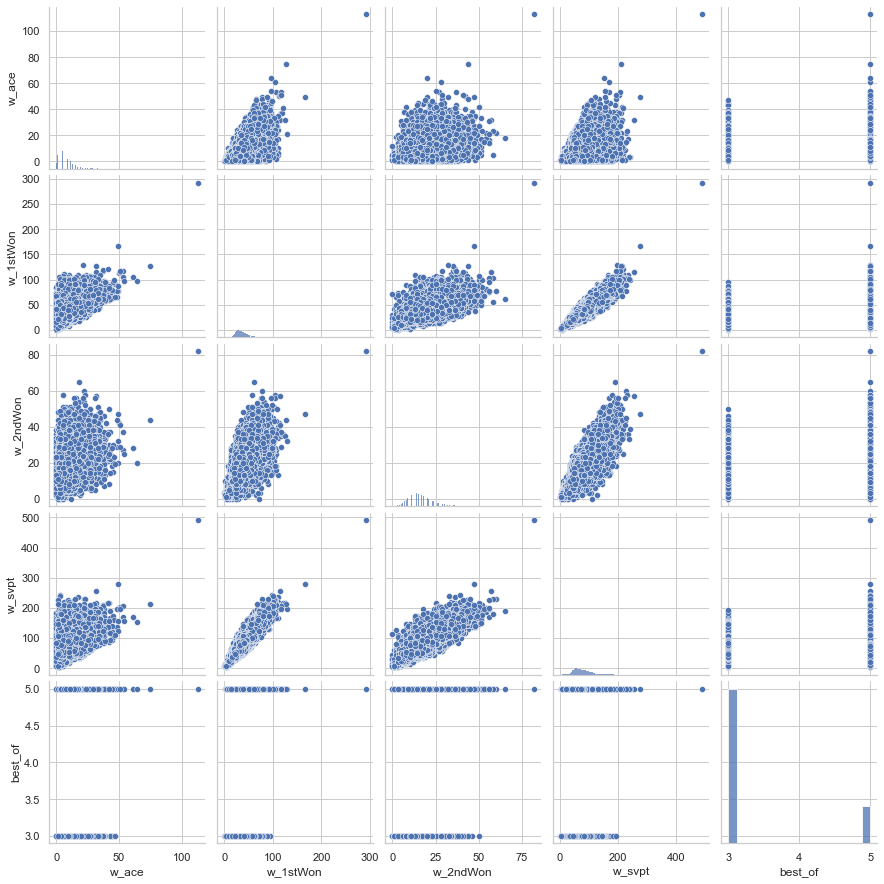

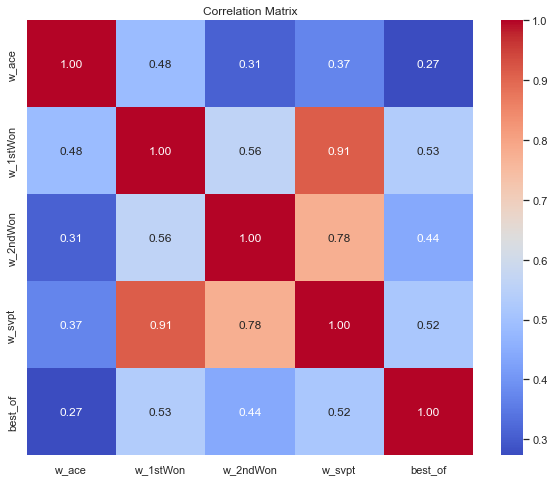

In [10]:
X, y = get_data()
# Check the data
print(X.describe())
print(y.describe())

# Plot the data
plot_data(X, y)

/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
  File "/opt/anaconda3/lib/python3.9/inspect.py", line 3043, in bind
    return self._bind(args, kwargs)
  File "/opt/anaconda3/lib/python3.9/inspect.py", line 3032, in _bind
    raise TypeError(
TypeError: got an unexpected keyword argument 'needs_proba'

  warnings.warn(
/opt/anaconda3/lib/python3.9

--- Logistic Regression CV Results ---
CV Accuracy : 0.776 ± 0.005
CV ROC-AUC  : nan ± nan

Logistic Regression Test Accuracy : 0.780
Logistic Regression Test ROC-AUC  : 0.852

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.71      0.72      4503
           1       0.81      0.82      0.82      6778

    accuracy                           0.78     11281
   macro avg       0.77      0.77      0.77     11281
weighted avg       0.78      0.78      0.78     11281

Confusion Matrix:
[[3212 1291]
 [1189 5589]]




/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
  File "/opt/anaconda3/lib/python3.9/inspect.py", line 3043, in bind
    return self._bind(args, kwargs)
  File "/opt/anaconda3/lib/python3.9/inspect.py", line 3032, in _bind
    raise TypeError(
TypeError: got an unexpected keyword argument 'needs_proba'

  warnings.warn(
/opt/anaconda3/lib/python3.9

--- Decision Tree CV Results ---
CV Accuracy : 0.691 ± 0.004
CV ROC-AUC  : nan ± nan
Decision Tree best params: {'max_depth': 10, 'min_samples_leaf': 10}

Decision Tree Test Accuracy : 0.760
Decision Tree Test ROC-AUC  : 0.833

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.66      0.69      4503
           1       0.78      0.83      0.81      6778

    accuracy                           0.76     11281
   macro avg       0.75      0.74      0.75     11281
weighted avg       0.76      0.76      0.76     11281

Confusion Matrix:
[[2956 1547]
 [1165 5613]]


Predictions for Logistic Regression (first 20): [1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1]
Predictions for Decision Tree (first 20): [1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1]


/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_7123/3450822025.py:304: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
/opt/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


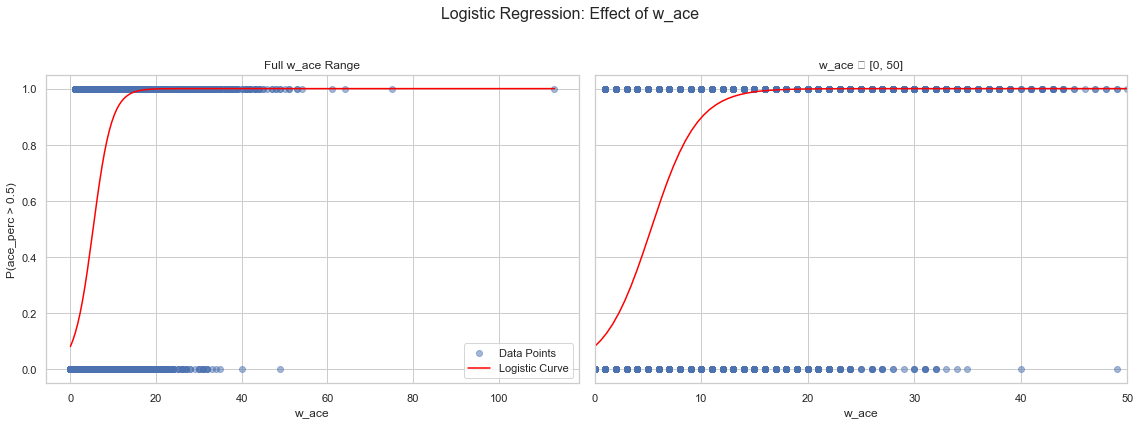

In [11]:
models = train_models(X, y, cv_folds=10)

# Example: predictions on full dataset
for name, mdl in models.items():
    preds = predict(mdl, X)
    print(f"Predictions for {name} (first 20):", preds[:20])

# Visualize LR
plot_logistic_regression(models["Logistic Regression"], X, y)